# AI & Machine Learning Task 2
## Feature Engineering, Model Optimization & Performance Comparison

Dataset Used:
California Housing Dataset

Objective:
To build and compare multiple regression models for predicting house prices and evaluate their performance using RMSE and R² Score.

# Step 1: Import Libraries
Import all required libraries for data manipulation, visualization, preprocessing, model building, and evaluation.

In [65]:
# Numerical computations
import numpy as np

# Data handling
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Dataset
from sklearn.datasets import fetch_california_housing

# Splitting dataset
from sklearn.model_selection import train_test_split

# Feature Scaling
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

# Evaluation Metrics
from sklearn.metrics import mean_squared_error, r2_score

# Step 2: Dataset Exploration
Explore the dataset structure, statistics, and missing values.

In [66]:
# Load California Housing Dataset
housing = fetch_california_housing()

# Convert into DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add Target Column
df["HousePrice"] = housing.target

# Display first five rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [67]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (20640, 9)


In [68]:
print(df.columns)

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'HousePrice'],
      dtype='object')


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   HousePrice  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [70]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [71]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
HousePrice,0


In [72]:
X = df.drop("HousePrice", axis=1)

y = df["HousePrice"]

# Step 3: Feature Scaling
Apply StandardScaler to normalize all input features before training machine learning models.

In [73]:
scaler = StandardScaler()

In [74]:
X_scaled = scaler.fit_transform(X)

In [75]:
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,2.344766,0.982143,0.628559,-0.153758,-0.974429,-0.049597,1.052548,-1.327835
1,2.332238,-0.607019,0.327041,-0.263336,0.861439,-0.092512,1.043185,-1.322844
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843,1.038503,-1.332827
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329,1.038503,-1.337818
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616,1.038503,-1.337818


In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [77]:
print(X_train.shape)
print(X_test.shape)

(16512, 8)
(4128, 8)


# Step 4: Linear Regression
Train the baseline regression model and evaluate its performance.

In [78]:
linear_model = LinearRegression()

In [79]:
linear_model.fit(X_train, y_train)

LinearRegression()

In [80]:
linear_predictions = linear_model.predict(X_test)

In [81]:
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))

In [82]:
linear_r2 = r2_score(y_test, linear_predictions)

In [83]:
print("Linear Regression")
print("RMSE:", linear_rmse)
print("R2 Score:", linear_r2)

Linear Regression
RMSE: 0.7455813830127762
R2 Score: 0.575787706032451


# Step 5: Ridge Regression
Train Ridge Regression to reduce overfitting and compare its performance.

In [84]:
ridge_model = Ridge(alpha=1.0)

In [85]:
ridge_model.fit(X_train, y_train)

Ridge()

In [86]:
ridge_predictions = ridge_model.predict(X_test)

In [87]:
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_predictions))

ridge_r2 = r2_score(y_test, ridge_predictions)

print("Ridge Regression")

print("RMSE:", ridge_rmse)

print("R2 Score:", ridge_r2)

Ridge Regression
RMSE: 0.7455542909384607
R2 Score: 0.5758185345441323


# Step 6: Decision Tree Regression
Train a Decision Tree Regressor to capture nonlinear relationships in the dataset.

In [88]:
tree_model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

In [89]:
tree_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [90]:
tree_predictions = tree_model.predict(X_test)

In [91]:
tree_rmse = np.sqrt(mean_squared_error(y_test, tree_predictions))

tree_r2 = r2_score(y_test, tree_predictions)

print("Decision Tree")

print("RMSE:", tree_rmse)

print("R2 Score:", tree_r2)

Decision Tree
RMSE: 0.7242338143386247
R2 Score: 0.5997321244428706


# Step 7: Performance Comparison
Compare all models using RMSE and R² Score.

In [92]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Decision Tree"
    ],
    "RMSE": [
        linear_rmse,
        ridge_rmse,
        tree_rmse
    ],
    "R2 Score": [
        linear_r2,
        ridge_r2,
        tree_r2
    ]
})

comparison = comparison.sort_values(by="R2 Score", ascending=False)

comparison

,Model,RMSE,R2 Score
2,Decision Tree,0.724234,0.599732
1,Ridge Regression,0.745554,0.575819
0,Linear Regression,0.745581,0.575788


In [93]:
best_model = comparison.loc[
    comparison["R2 Score"].idxmax()
]

print(best_model)

Model       Decision Tree
RMSE             0.724234
R2 Score         0.599732
Name: 2, dtype: object


# Step 8: Actual vs Predicted Visualization
Visualize the prediction accuracy using a scatter plot.

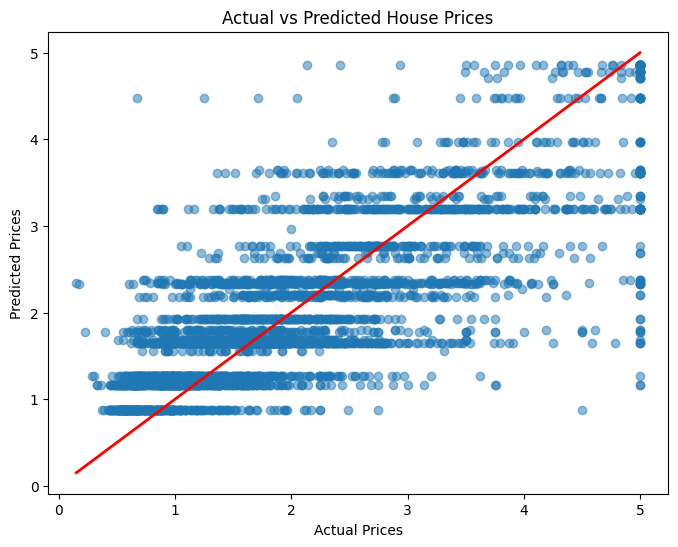

In [94]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    tree_predictions,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()

# Observations

- The California Housing dataset contained no missing values.
- StandardScaler was applied successfully to normalize the feature values.
- Linear Regression and Ridge Regression produced nearly identical results.
- The Decision Tree Regressor achieved the lowest prediction error (RMSE = 0.724234).
- The Decision Tree Regressor achieved the highest R² Score (0.599732), making it the best-performing model among the three.
- The Actual vs Predicted plot showed that the model predictions were reasonably close to the actual house prices, indicating satisfactory predictive performance.

# Conclusion

In this task, the California Housing dataset was successfully loaded, explored, and preprocessed. Feature scaling was applied using StandardScaler to normalize the input features before training the machine learning models.

Three regression algorithms—Linear Regression, Ridge Regression, and Decision Tree Regressor—were trained and evaluated using RMSE (Root Mean Squared Error) and R² Score.

The performance comparison showed that the Decision Tree Regressor outperformed the other models with an RMSE of **0.724234** and an R² Score of **0.599732**. These results indicate that the Decision Tree model was able to capture the relationships between the input features and house prices more effectively than the linear models.

Overall, this task demonstrated the importance of feature preprocessing, model comparison, and performance evaluation in selecting the most suitable machine learning model for a regression problem.